In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A
import requests
from io import BytesIO
from PIL import Image
import random
import torch
from tqdm.notebook import tqdm
import torch.nn as nn 
from torch._C import device
import torch.optim as optim
import torch.autograd.grad_mode as grad_mode
from torch.utils.data import dataset,DataLoader
from torch.autograd import Function as F 
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.rpn import AnchorGenerator

In [2]:
if torch.cuda.is_available():
    device=torch.device("cuda")
else:
    device=torch.device('cpu')

In [3]:
device

device(type='cuda')

In [6]:
def imageshow(number,title=None,size=5):
    root="../data/"
    image=cv2.imread(root+'Images/'+str(number)+".jpeg")
    
    file=open(root+"Labels/"+str(number)+".txt",'r')
    txt_data=file.readlines()
    file.close()
    
    for i in range(0,int(txt_data[0])):
        indices=[int(x) for x in txt_data[i+1].split()]
        start_point=(indices[0],indices[1])
        end_point=(indices[2],indices[3])
        
        cv2.rectangle(image,start_point,end_point,(0,0,255),2)
        
    aspect_ratio=image.shape[0]/image.shape[1]
    
    plt.figure(figsize=(size+aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))
    plt.title(title+txt_data[0])
    plt.show()

    

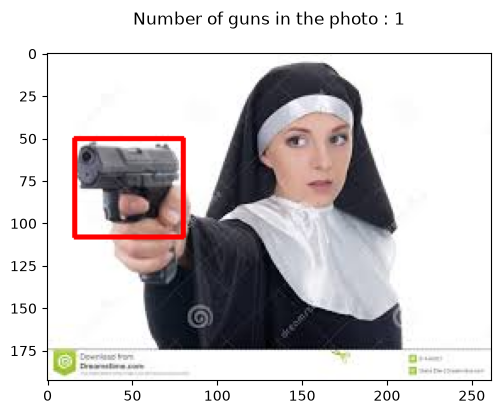

In [14]:
imageshow(120,title="Number of guns in the photo : ")